<a href="https://colab.research.google.com/github/Mohames-wael/signals-1/blob/main/signal_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from mne.filter import filter_data

In [ ]:
import os
import numpy as np
import mne
import xml.etree.ElementTree as ET
from mne.filter import filter_data

# -------------------- Paths --------------------
signal_path = "/content/drive/MyDrive/Dataset/Signals"
annotation_path = "/content/drive/MyDrive/Dataset/Annotations"

# -------------------- Containers --------------------
X_all = []
y_all = []
patient_ids = []
skipped_patients = []

edf_files = [f for f in os.listdir(signal_path) if f.endswith(".edf")]

# -------------------- Loop over patients --------------------
for file in edf_files:

    patient_id = file.replace(".edf","")

    print("\n" + "="*50)
    print("Checking patient:", patient_id)

    xml_file = os.path.join(annotation_path, patient_id + "-nsrr.xml")

    if not os.path.exists(xml_file):
        print("❌ XML not found")
        skipped_patients.append({'id':patient_id,'reason':'XML missing'})
        continue

    try:

        # -------------------- Read EDF --------------------
        edf_file = os.path.join(signal_path,file)

        raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)

        print("Channels:", raw.ch_names)

        # -------------------- Find EKG channel --------------------
        ekg_channel = None

        for ch in raw.ch_names:
            if "EKG" in ch.upper():
                ekg_channel = ch
                break

        if ekg_channel is None:
            for ch in raw.ch_names:
                if "ECG" in ch.upper():
                    ekg_channel = ch
                    break

        if ekg_channel is None:
            print("❌ No EKG/ECG channel found")
            skipped_patients.append({'id':patient_id,'reason':'No ECG/EKG'})
            continue

        print("✅ Using channel:", ekg_channel)

        ecg = raw.get_data(picks=[ekg_channel])[0]

        fs = int(raw.info['sfreq'])

        print("Sampling rate:", fs)

        # -------------------- Signal check --------------------
        if len(ecg) < fs*60:
            print("❌ Signal too short")
            skipped_patients.append({'id':patient_id,'reason':'Short signal'})
            continue

        # -------------------- Filtering --------------------
        ecg = filter_data(ecg, sfreq=fs, l_freq=0.5, h_freq=45, verbose=False)

        # normalization
        ecg = (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)

        # -------------------- Read XML --------------------
        tree = ET.parse(xml_file)
        root = tree.getroot()

        window = fs * 30

        segments = []
        labels = []

        event_count = 0

        for event in root.iter("ScoredEvent"):
            concept = event.find("EventConcept")
            if concept is not None:
                event_count += 1

        print("Events found:", event_count)

        if event_count == 0:
            skipped_patients.append({'id':patient_id,'reason':'No events'})
            continue

        # -------------------- Process events --------------------
        valid_segments = 0

        for event in root.iter("ScoredEvent"):

            concept = event.find("EventConcept")

            if concept is None:
                continue

            text = concept.text.lower()

            if "|" in text:
                stage_text = text.split("|")[0].strip()
            else:
                stage_text = text

            # -------------------- Stage mapping --------------------
            if "wake" in stage_text:
                label = 0

            elif "stage 1" in stage_text:
                label = 1

            elif "stage 2" in stage_text:
                label = 2

            elif "stage 3" in stage_text or "stage 4" in stage_text:
                label = 3

            elif "rem" in stage_text:
                label = 4

            else:
                continue

            try:

                start_time = float(event.find("Start").text)
                duration = float(event.find("Duration").text)

                start_sample = int(start_time * fs)
                end_sample = int((start_time + duration) * fs)

                if end_sample > len(ecg):
                    continue

                # -------------------- Segmentation --------------------
                for start in range(start_sample, end_sample, window):

                    end = start + window

                    if end > len(ecg):
                        break

                    segment = ecg[start:end]

                    if len(segment) == window:

                        segments.append(segment)
                        labels.append(label)
                        valid_segments += 1

            except:
                continue

        if len(segments) == 0:

            print("❌ No segments extracted")

            skipped_patients.append({'id':patient_id,'reason':'No segments'})
            continue

        X = np.array(segments)
        y = np.array(labels)

        print("✅ Segments:", len(X))

        unique, counts = np.unique(y, return_counts=True)

        stage_names = ['Wake','N1','N2','N3','REM']

        print("Class distribution:")

        for u,c in zip(unique,counts):

            print(stage_names[u],":",c)

        # -------------------- Append --------------------
        X_all.extend(X)
        y_all.extend(y)
        patient_ids.extend([patient_id]*len(X))

    except Exception as e:

        print("❌ Error:", e)

        skipped_patients.append({'id':patient_id,'reason':str(e)})

# -------------------- Final Results --------------------

print("\n"+"="*60)
print("FINAL RESULTS")
print("="*60)

print("Total EDF files:", len(edf_files))

print("Processed patients:", len(np.unique(patient_ids)))

print("Skipped patients:", len(skipped_patients))

print("\nSkipped details:")

for skip in skipped_patients:

    print(skip['id'],":",skip['reason'])

# -------------------- Dataset summary --------------------

if len(X_all) > 0:

    X_all = np.array(X_all)
    y_all = np.array(y_all)
    patient_ids = np.array(patient_ids)

    print("\n"+"="*60)
    print("DATASET SUMMARY")
    print("="*60)

    print("X shape:", X_all.shape)
    print("y shape:", y_all.shape)

    unique, counts = np.unique(y_all, return_counts=True)

    stage_names = {
        0:'Wake',
        1:'N1',
        2:'N2',
        3:'N3',
        4:'REM'
    }

    print("\nClass distribution:")

    for u,c in zip(unique,counts):

        print(stage_names[u],":",c,"(",round(c/len(y_all)*100,2),"%)")


Checking patient: mesa-sleep-0001
Channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ Using channel: EKG
Sampling rate: 256
Events found: 1142
✅ Segments: 1439
Class distribution:
Wake : 752
N1 : 135
N2 : 455
N3 : 19
REM : 78

Checking patient: mesa-sleep-0006
Channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ Using channel: EKG
Sampling rate: 256
Events found: 1902
✅ Segments: 1079
Class distribution:
Wake : 364
N1 : 141
N2 : 380
N3 : 75
REM : 119

Checking patient: mesa-sleep-0002
Channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Tho

In [ ]:
import pickle

output_dir = "/content/drive/MyDrive/ECG_dataset"
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, "X.pkl"), "wb") as f:
    pickle.dump(X_all, f)
with open(os.path.join(output_dir, "y.pkl"), "wb") as f:
    pickle.dump(y_all, f)
with open(os.path.join(output_dir, "patient_ids.pkl"), "wb") as f:
    pickle.dump(patient_ids, f)  # ADD THIS

NameError: name 'os' is not defined

In [ ]:
import pickle

with open("/content/drive/MyDrive/ECG_dataset/X.pkl","rb") as f:
    X = pickle.load(f)

with open("/content/drive/MyDrive/ECG_dataset/y.pkl","rb") as f:
    y = pickle.load(f)

with open("/content/drive/MyDrive/ECG_dataset/patient_ids.pkl","rb") as f:
    patient_ids = pickle.load(f)

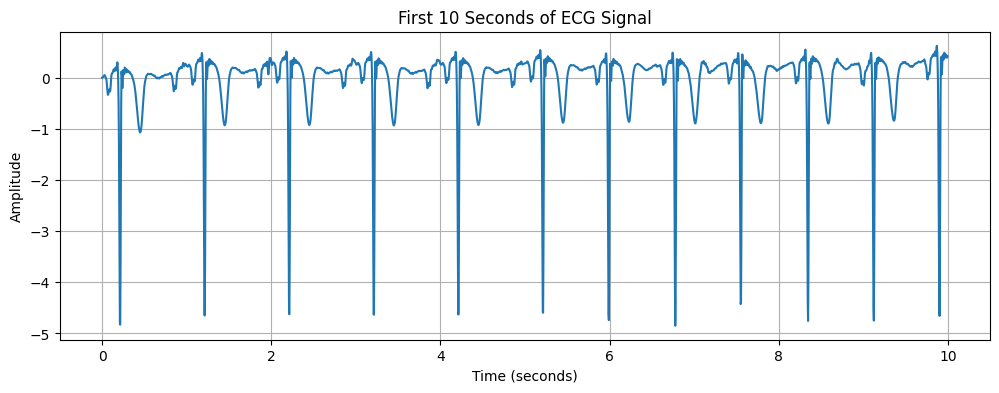

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
sampling_rate = 256
n_points_10s = sampling_rate * 10  # 2560
time_axis = np.arange(n_points_10s) / sampling_rate  # محور الزمن من 0 لـ 10 ثوانى

# رسم أول 10 ثوانى من أول عينة
if X.ndim == 2:  # shape (samples, time_points)
    signal = X[0, :n_points_10s]
elif X.ndim == 3:  # shape (samples, channels, time_points)
    signal = X[0, 0, :n_points_10s]  # أول عينة، أول قناة
else:
    signal = X[:n_points_10s]

# الرسم
plt.figure(figsize=(12, 4))
plt.plot(time_axis, signal)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('First 10 Seconds of ECG Signal')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
X = X[:, ::10]
X = X.reshape(X.shape[0], X.shape[1], 1)
X = X.astype(np.float32)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
print(np.unique(y, return_counts=True))

(array([0, 1, 2, 3, 4]), array([5569,  942, 4117,  869, 1261]))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
n1_idx = np.where(y_train == 1)[0]

X_n1 = X_train[n1_idx]
y_n1 = y_train[n1_idx]

# نكرر N1 مرتين
X_train = np.concatenate([X_train, X_n1, X_n1])
y_train = np.concatenate([y_train, y_n1, y_n1])

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=5)

        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

        pt = tf.exp(-ce)

        loss = alpha * tf.pow((1 - pt), gamma) * ce

        return loss

    return loss

In [ ]:
noise = np.random.normal(0,0.05,X_train.shape)

X_train_aug = X_train + noise

X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train])

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def residual_block(x, filters):
    shortcut = x

    x = Conv1D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

In [ ]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs,inputs)

    x = Dropout(dropout)(x)

    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)

    x_ff = Dense(ff_dim,activation="relu")(x)
    x_ff = Dropout(dropout)(x_ff)

    x_ff = Dense(inputs.shape[-1])(x_ff)

    res = x_ff + x

    return LayerNormalization(epsilon=1e-6)(res)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input

input_layer = Input(shape=(768,1))
x = residual_block(input_layer,64)
x = MaxPooling1D(2)(x)
x = residual_block(x,128)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
seq_len = x.shape[1]
d_model = x.shape[2]

for _ in range(5):
    x = transformer_encoder(
        x,
        head_size=32,
        num_heads=4,
        ff_dim=128,
        dropout=0.3
    )
x = GlobalAveragePooling1D()(x)
x = Dense(128,activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(5,activation="softmax")(x)
model = Model(input_layer,output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 768, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 768, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 768, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 768, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 768, 64)   │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 768, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 768, 64)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 768, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 768, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 384, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 384, 128)  │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 384, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 384, 128)  │     49,280 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 384, 128)  │      8,320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 384, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 384, 128)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 128)  │        512 │ activation_3[0][

 Total params: 620,869 (2.37 MB)

 Trainable params: 619,461 (2.36 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss=focal_loss(),
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3810 - loss: 0.2927

367/367 ━━━━━━━━━━━━━━━━━━━━ 91s 136ms/step - accuracy: 0.4512 - loss: 0.2289 - val_accuracy: 0.2676 - val_loss: 0.4807 - learning_rate: 5.0000e-04
Epoch 2/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5112 - loss: 0.1782

367/367 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.5228 - loss: 0.1705 - val_accuracy: 0.5282 - val_loss: 0.1626 - learning_rate: 5.0000e-04
Epoch 3/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5132 - loss: 0.1742

367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.5350 - loss: 0.1632 - val_accuracy: 0.6720 - val_loss: 0.1323 - learning_rate: 5.0000e-04
Epoch 4/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.5703 - loss: 0.1480 - val_accuracy: 0.5031 - val_loss: 0.1651 - learning_rate: 5.0000e-04
Epoch 5/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.5653 - loss: 0.1462 - val_accuracy: 0.6481 - val_loss: 0.1345 - learning_rate: 5.0000e-04
Epoch 6/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.5892 - loss: 0.1341 - val_accuracy: 0.6223 - val_loss: 0.1294 - learning_rate: 5.0000e-04
Epoch 7/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.5963 - loss: 0.1270 - val_accuracy: 0.6661 - val_loss: 0.1067 - learning_rate: 5.0000e-04
Epoch 8/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6105 - loss: 0.1189 - val_accuracy: 0.6650 - val_loss: 0.1263 - learning_rate: 5.0000e-04
Epoch 9/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accurac

367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6348 - loss: 0.1078 - val_accuracy: 0.7026 - val_loss: 0.0980 - learning_rate: 5.0000e-04
Epoch 12/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6549 - loss: 0.1002 - val_accuracy: 0.6877 - val_loss: 0.0981 - learning_rate: 5.0000e-04
Epoch 13/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6655 - loss: 0.0960 - val_accuracy: 0.6814 - val_loss: 0.1154 - learning_rate: 5.0000e-04
Epoch 14/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6754 - loss: 0.0940 - val_accuracy: 0.6834 - val_loss: 0.1023 - learning_rate: 5.0000e-04
Epoch 15/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6910 - loss: 0.0891

...

367/367 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.7328 - loss: 0.0702 - val_accuracy: 0.7175 - val_loss: 0.1088 - learning_rate: 5.0000e-04
Epoch 21/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.7363 - loss: 0.0685 - val_accuracy: 0.7096 - val_loss: 0.1067 - learning_rate: 5.0000e-04
Epoch 22/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.7223 - loss: 0.0754 - val_accuracy: 0.7022 - val_loss: 0.1059 - learning_rate: 5.0000e-04
Epoch 23/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7285 - loss: 0.0744

367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.7437 - loss: 0.0677 - val_accuracy: 0.7363 - val_loss: 0.0861 - learning_rate: 5.0000e-04
Epoch 24/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.7672 - loss: 0.0587 - val_accuracy: 0.6575 - val_loss: 0.1306 - learning_rate: 5.0000e-04
Epoch 25/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.7533 - loss: 0.0623 - val_accuracy: 0.7241 - val_loss: 0.1041 - learning_rate: 5.0000e-04
Epoch 26/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.7756 - loss: 0.0561 - val_accuracy: 0.6226 - val_loss: 0.1385 - learning_rate: 5.0000e-04
Epoch 27/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.7789 - loss: 0.0562 - val_accuracy: 0.7022 - val_loss: 0.0966 - learning_rate: 5.0000e-04
Epoch 28/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.7792 - loss: 0.0548 - val_accuracy: 0.7187 - val_loss: 0.1176 - learning_rate: 5.0000e-04
Epoch 29/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - a

367/367 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.8381 - loss: 0.0366 - val_accuracy: 0.7410 - val_loss: 0.1066 - learning_rate: 2.5000e-04
Epoch 31/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8251 - loss: 0.0402 - val_accuracy: 0.7312 - val_loss: 0.1186 - learning_rate: 2.5000e-04
Epoch 32/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8490 - loss: 0.0331

367/367 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.8505 - loss: 0.0332 - val_accuracy: 0.7524 - val_loss: 0.1047 - learning_rate: 2.5000e-04
Epoch 33/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.8416 - loss: 0.0359 - val_accuracy: 0.7316 - val_loss: 0.1114 - learning_rate: 2.5000e-04
Epoch 34/40
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8516 - loss: 0.0350

367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.8673 - loss: 0.0296 - val_accuracy: 0.7696 - val_loss: 0.1060 - learning_rate: 1.2500e-04
Epoch 35/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8816 - loss: 0.0250 - val_accuracy: 0.7359 - val_loss: 0.1174 - learning_rate: 1.2500e-04
Epoch 36/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.8819 - loss: 0.0246 - val_accuracy: 0.7343 - val_loss: 0.1135 - learning_rate: 1.2500e-04
Epoch 37/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8899 - loss: 0.0236 - val_accuracy: 0.7512 - val_loss: 0.1138 - learning_rate: 1.2500e-04
Epoch 38/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8909 - loss: 0.0233 - val_accuracy: 0.7382 - val_loss: 0.1220 - learning_rate: 1.2500e-04
Epoch 39/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.8974 - loss: 0.0211 - val_accuracy: 0.7684 - val_loss: 0.1137 - learning_rate: 6.2500e-05
Epoch 40/40
367/367 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - a

In [ ]:
model.save('/content/drive/MyDrive/final_model1.keras')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/final_model1.keras')

TypeError: Could not locate function 'loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'loss', 'registered_name': 'function'}

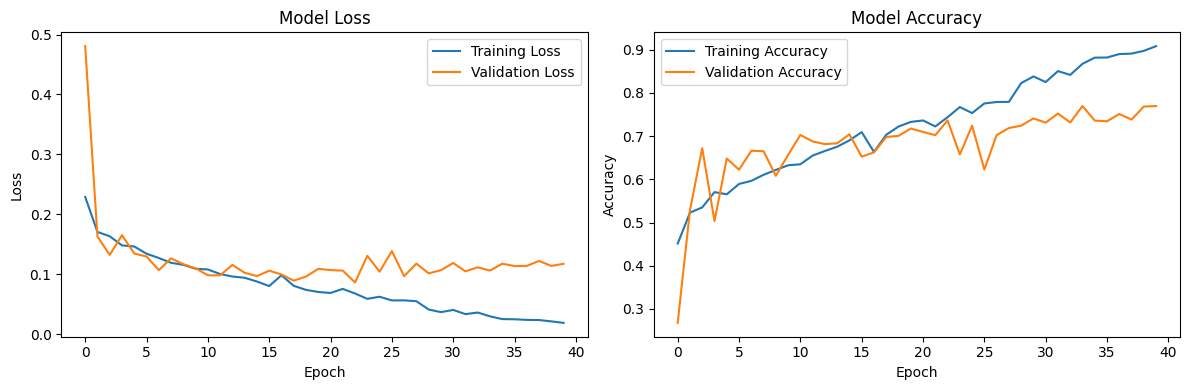

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # رسم Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # رسم Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()
plot_training_history(history)

In [ ]:
model.evaluate(X_test,y_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7696 - loss: 0.1060


[0.10598891228437424, 0.7695924639701843]

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step
Test Accuracy: 0.7695924764890282


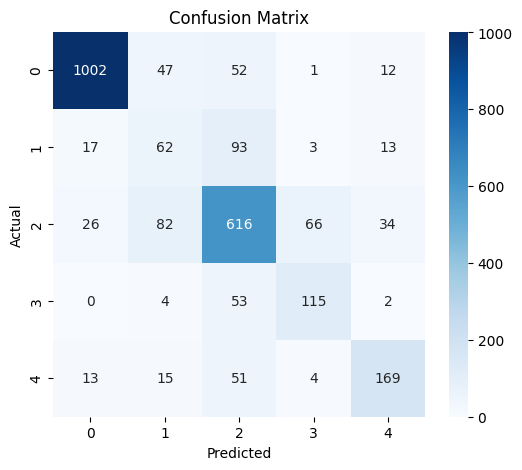

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
labels = [str(i) for i in np.unique(y_test)]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(y_test, y_pred, target_names=labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1114
           1       0.30      0.33      0.31       188
           2       0.71      0.75      0.73       824
           3       0.61      0.66      0.63       174
           4       0.73      0.67      0.70       252

    accuracy                           0.77      2552
   macro avg       0.66      0.66      0.66      2552
weighted avg       0.78      0.77      0.77      2552



80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


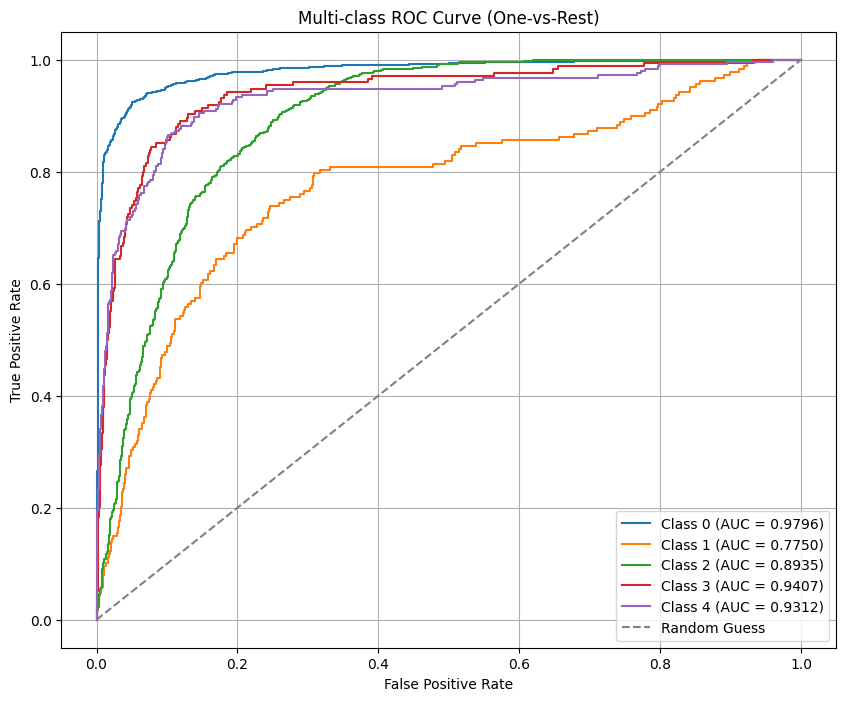

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
y_pred_proba = model.predict(X_test)
y_test_one_hot = to_categorical(y_test, num_classes=len(np.unique(y_test)))

plt.figure(figsize=(10, 8))

for i in range(len(np.unique(y_test))):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()